In [127]:
from matplotlib import pyplot as plt


class GameOfLife(object):
    def __init__(self, x_dim: int, y_dim: int) -> None:
        """This is the constructor it is used to inialize the Class




        Args:
            x_dim: This is the number of rows of the grid
            y_dim: This is the number of columns of the grid
        """
        # Initialize a 2D list with dimensions x_dim by y_dim filled with zeros.
        self.x_dim = x_dim
        self.y_dim = y_dim
        self.grid = []
        for row in range(x_dim):
            self.grid.append([])
            for _ in range(y_dim):
                self.grid[row].append(0)

    @property
    def get_grid(self) -> list[list[int]]:
        """This a property function, it just returns the grid




        Returns:
            The grid which is a list of lists
        """
        # Implement a getter method for your grid.
        return self.grid

    def print_grid(self):
        """This function prints the grid"""
        # Implement a method to print out your grid in a human-readable format.
        for row in self.grid:
            for col in row:
                print(col, end=" | ")
            print("\n", "- " * (len(row) * 2), sep="")

    def populate_grid(self, coord: list[tuple]) -> list[list[int]]:
        """This is used at the inial state to start the game




        Args:
            coord: It is a list of tuples, each tuple contains x and y coordiantes

        Returns:
            The grid
        """
        # Given a list of 2D coordinates (represented as s/lists with 2 elements each),
        # set the corresponding elements in your grid to 1.
        self.coord = coord
        for tup in coord:
            self.grid[tup[0]][tup[1]] = 1
        return self.grid

    def make_step(self):
        """This the function that updates the grid one single time




        Returns:
            The grid after the update
        """
        # Implement the logic to update the game state according to the rules of Conway's Game of Life.
        neighbors = 0
        changes = {}
        for row in range(len(self.grid)):
            for col in range(len(self.grid[row])):
                for adj in [
                    (-1, 0),
                    (-1, 1),
                    (0, 1),
                    (1, 1),
                    (1, 0),
                    (1, -1),
                    (0, -1),
                    (-1, -1),
                ]:
                    if (
                        (len(self.grid) > row + adj[0] >= 0)
                        and ((len(self.grid[row]) > col + adj[1] >= 0))
                    ) and (self.grid[row + adj[0]][col + adj[1]] == 1):
                        neighbors += 1
                if self.grid[row][col] == 1 and (neighbors == 3 or neighbors == 2):
                    changes[(row, col)] = 1
                elif self.grid[row][col] == 0 and neighbors == 3:
                    changes[(row, col)] = 1
                else:
                    changes[(row, col)] = 0
                neighbors = 0
        for key, value in changes.items():
            self.grid[key[0]][key[1]] = value
        return self.grid
    def make_n_steps(self, n):
        '''  This function updates the game by n times


        
        
        Args:
            n: Number of updates to be done
        
        Returns:
            The grid upated n times
        '''
        # Implement a method that applies the make_step method n times.
        for _ in range(n):
            self.make_step()
        return self.grid
    
    def draw_grid(self):
        '''  Draws a scatter plot with green being the living cells and red being the dead cells'''
        # Draw the current state of the grid.
        xs = []
        ys = []
        color_list = []
        for x in range(len(self.grid)):
            for y in range(len(self.grid[x])):
                xs.append(y)
                ys.append(-x)
                if self.grid[x][y] == 0:
                    color_list.append("red")
                else:
                    color_list.append("green")
        plt.scatter(xs, ys, c=color_list)
        plt.show

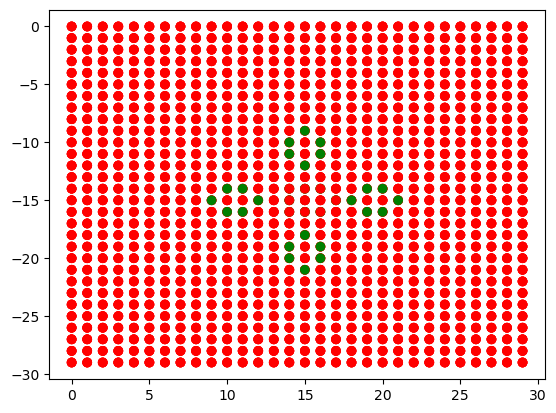

In [136]:
grid = GameOfLife(30, 30)
grid.draw_grid()
grid.populate_grid([(14, 15), (15, 15), (16, 15), (15, 14), (16, 16), (14, 16), (15, 17)])
grid.draw_grid()
grid.make_step()
grid.draw_grid()
grid.make_n_steps(16)
grid.draw_grid()

[[0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,

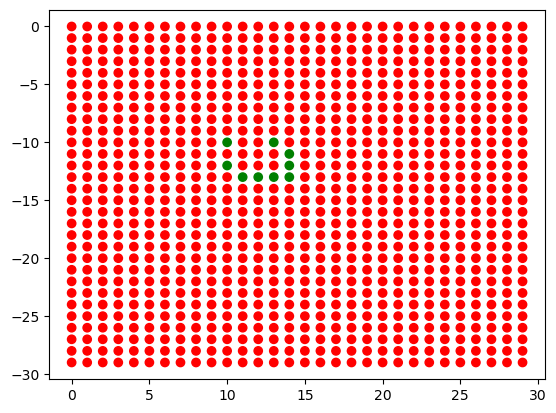

In [142]:
grid2 = GameOfLife(30, 30)
grid2.populate_grid([(10, 10), (10, 13), (11, 14), (12, 10), (12, 14), (13, 11), (13, 12), (13, 13), (13, 14)])
grid2.draw_grid()
grid2.make_n_steps(12)

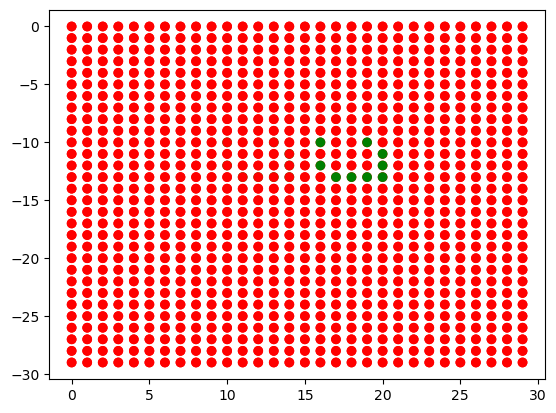

In [ ]:

grid2.draw_grid()

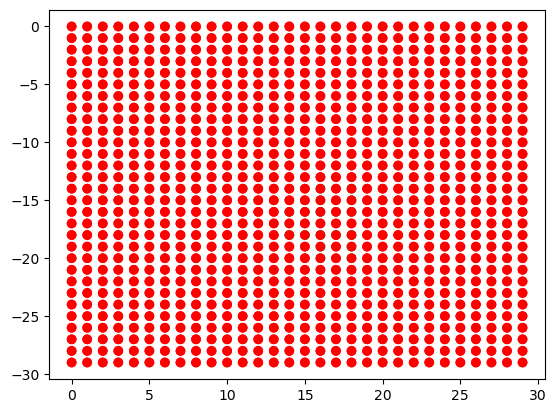

In [163]:
g = GameOfLife(30, 30)
g.populate_grid([(14, 16), (15, 16), (16, 16), (18, 16), (19, 16), (20, 16),
(16, 14), (16, 15), (16, 17), (16, 18),
(18, 14), (18, 15), (18, 17), (18, 18),
(14, 18), (15, 18), (16, 18), (18, 18), (19, 18), (20, 18)])
g.draw_grid()
g.make_n_steps(6)
g.draw_grid()

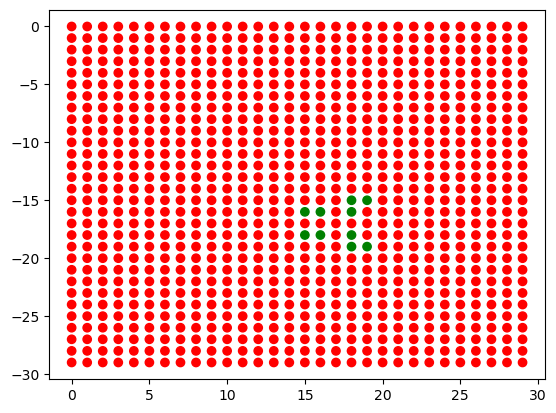

In [155]:
g.make_step
g.draw_grid()